## 1. Setup and Imports

In [7]:
# ! pip install lime

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from lime.lime_text import LimeTextExplainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"✅ Libraries loaded successfully!")


c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cuda
✅ Libraries loaded successfully!


## 2. Model Loading Configuration

In [8]:
# Define model paths - modify these to compare different models
MODEL_1_PATH = '../../models/bert_fake_news_trained_v2'          # Model 1 to compare
MODEL_1_NAME = 'Combined Specialist'

MODEL_2_PATH = '../../models/bert_politifact_retrained'       # Model 2 to compare
MODEL_2_NAME = 'Political Specialist'

# Results file configuration
RESULTS_FILE = 'playground_results.txt'

# You can also swap in the combined model:
# MODEL_2_PATH = '../../models/bert_fake_news_trained_v2'
# MODEL_2_NAME = 'Combined General'

print(f"📊 Model Configuration:")
print(f"  Model 1: {MODEL_1_NAME} ({MODEL_1_PATH})")
print(f"  Model 2: {MODEL_2_NAME} ({MODEL_2_PATH})")
print(f"  Results file: {RESULTS_FILE}")

📊 Model Configuration:
  Model 1: Combined Specialist (../../models/bert_fake_news_trained_v2)
  Model 2: Political Specialist (../../models/bert_politifact_retrained)
  Results file: playground_results.txt


## 3. Load Models

In [9]:
# Load Model 1
print(f"\n🔄 Loading {MODEL_1_NAME}...")
try:
    if 'model_1' not in locals() or model_1 is None:
        model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_1_PATH)
        tokenizer_1 = AutoTokenizer.from_pretrained(MODEL_1_PATH)
        model_1.to(device)
        model_1.eval()
        print(f"✅ {MODEL_1_NAME} loaded successfully!")
    else:
        print(f"✅ {MODEL_1_NAME} already loaded!")
except Exception as e:
    print(f"❌ Error: {e}")
    model_1 = None

# Load Model 2
print(f"\n🔄 Loading {MODEL_2_NAME}...")
try:
    if 'model_2' not in locals() or model_2 is None:
        model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_2_PATH)
        tokenizer_2 = AutoTokenizer.from_pretrained(MODEL_2_PATH)
        model_2.to(device)
        model_2.eval()
        print(f"✅ {MODEL_2_NAME} loaded successfully!")
    else:
        print(f"✅ {MODEL_2_NAME} already loaded!")
except Exception as e:
    print(f"❌ Error: {e}")
    model_2 = None

print(f"\n✅ Both models ready for comparison!")



🔄 Loading Combined Specialist...
✅ Combined Specialist loaded successfully!

🔄 Loading Political Specialist...
✅ Political Specialist loaded successfully!

✅ Both models ready for comparison!
✅ Combined Specialist loaded successfully!

🔄 Loading Political Specialist...
✅ Political Specialist loaded successfully!

✅ Both models ready for comparison!


## 4. Prediction Function

In [5]:
def predict_text(text, model, tokenizer, device):
    """Get prediction and confidence for a text sample"""
    if model is None:
        return None, None, None
    
    text = str(text).strip()
    if not text:
        return None, None, None
    
    try:
        inputs = tokenizer(
            text,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            prediction = torch.argmax(logits, dim=-1).item()
            fake_prob = probs[0][0].item()
            real_prob = probs[0][1].item()
        
        return prediction, {'fake': fake_prob, 'real': real_prob}, max(fake_prob, real_prob)
    except Exception as e:
        print(f"Error: {e}")
        return None, None, None

def save_results(test_article, pred_1, probs_1, conf_1, pred_2, probs_2, conf_2, model_1_name, model_2_name, results_file):
    """Save prediction results to a text file"""
    from datetime import datetime
    
    pred_1_label = 'REAL' if pred_1 == 1 else 'FAKE' if pred_1 == 0 else 'ERROR'
    pred_2_label = 'REAL' if pred_2 == 1 else 'FAKE' if pred_2 == 0 else 'ERROR'
    
    with open(results_file, 'a', encoding='utf-8') as f:
        f.write("\n" + "="*100 + "\n")
        # Count existing tests by counting = lines
        try:
            with open(results_file, 'r', encoding='utf-8') as rf:
                test_num = rf.read().count("="*100) // 2
        except:
            test_num = 0
        f.write(f"Test #{test_num}\n")
        f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*100 + "\n\n")
        
        # Article preview (first 300 chars)
        article_preview = test_article.strip()[:300] + "..." if len(test_article.strip()) > 300 else test_article.strip()
        f.write(f"ARTICLE TESTED:\n{article_preview}\n\n")
        
        # Model 1 results
        f.write(f"{'─'*100}\n")
        f.write(f"{model_1_name}:\n")
        f.write(f"  Prediction: {pred_1_label}\n")
        if probs_1:
            f.write(f"  Fake Probability: {probs_1['fake']:.4f} ({probs_1['fake']:.2%})\n")
            f.write(f"  Real Probability: {probs_1['real']:.4f} ({probs_1['real']:.2%})\n")
            f.write(f"  Confidence: {conf_1:.4f} ({conf_1:.2%})\n")
        f.write("\n")
        
        # Model 2 results
        f.write(f"{model_2_name}:\n")
        f.write(f"  Prediction: {pred_2_label}\n")
        if probs_2:
            f.write(f"  Fake Probability: {probs_2['fake']:.4f} ({probs_2['fake']:.2%})\n")
            f.write(f"  Real Probability: {probs_2['real']:.4f} ({probs_2['real']:.2%})\n")
            f.write(f"  Confidence: {conf_2:.4f} ({conf_2:.2%})\n")
        f.write("\n")
        
        # Agreement/Disagreement
        f.write(f"{'─'*100}\n")
        if pred_1 == pred_2:
            f.write(f"✅ Models AGREE: Both predict {pred_1_label}\n")
        else:
            f.write(f"⚠️  Models DISAGREE: {model_1_name} says {pred_1_label}, {model_2_name} says {pred_2_label}\n")
        f.write("\n")

print("✅ Prediction and logging functions ready")


✅ Prediction and logging functions ready


## 5. Setup LIME Explainers

In [10]:
def create_predictor(model, tokenizer, device):
    """Create prediction function for LIME"""
    def predict_fn(texts):
        predictions = []
        for text in texts:
            text = str(text) if isinstance(text, (list, tuple)) else text
            pred, probs, conf = predict_text(text, model, tokenizer, device)
            if probs:
                predictions.append([probs['fake'], probs['real']])
            else:
                predictions.append([0.5, 0.5])
        return np.array(predictions)
    return predict_fn

# Create LIME explainers
print("⚙️  Setting up LIME explainers...")
explainer_1 = LimeTextExplainer(class_names=['Fake News', 'Real News'])
explainer_2 = LimeTextExplainer(class_names=['Fake News', 'Real News'])

predictor_1 = create_predictor(model_1, tokenizer_1, device) if model_1 else None
predictor_2 = create_predictor(model_2, tokenizer_2, device) if model_2 else None

print("✅ LIME explainers ready")

⚙️  Setting up LIME explainers...
✅ LIME explainers ready


## 6. 🎮 PLAYGROUND: Test Your Article Here!

Replace the article below with any text you want to test. Both models will analyze it and show which words influence their predictions.

In [ ]:
# ===== LOAD POLITIFACT TEST DATA =====
import os
import pandas as pd

workspace_root = r'c:\Users\aweso\Documents\fakenews-analysis'
data_dir = os.path.join(workspace_root, 'data', 'processed', '00')
test_file = os.path.join(data_dir, 'politifact_test.csv')

print("Loading PolitiFact test data...")
test_df = pd.read_csv(test_file)
test_df = test_df.rename(columns={'news': 'Article', 'label': 'Truth'})
test_df = test_df[['Article', 'Truth']].copy()

print(f"\n✅ Loaded {len(test_df)} test articles")
print(f"\nClass distribution:")
print(test_df['Truth'].value_counts())

# ===== SELECT TEST ARTICLES FROM POLITIFACT TEST SET =====
# Pick a few examples to analyze in detail

# You can modify these indices to test different articles
test_indices = [0, 5, 10, 15]  # Pick 4 articles to analyze

print("\n" + "="*80)
print("📰 Test Articles from PolitiFact Test Set:")
print("="*80)

for idx in test_indices:
    if idx < len(test_df):
        article = test_df['Article'].iloc[idx]
        truth = test_df['Truth'].iloc[idx]
        label = 'REAL' if truth == 1 else 'FAKE'
        print(f"\nArticle #{idx} (Ground Truth: {label})")
        print("-" * 80)
        print(article[:300] + "..." if len(article) > 300 else article)
        print()

# For detailed analysis, we'll use the first article
test_index = 0
test_article = test_df['Article'].iloc[test_index]
ground_truth = test_df['Truth'].iloc[test_index]
ground_truth_label = 'REAL' if ground_truth == 1 else 'FAKE'

print("\n" + "="*80)
print(f"DETAILED ANALYSIS: Article #{test_index}")
print(f"Ground Truth: {ground_truth_label}")
print("="*80)
print(test_article)
print("="*80)


## 9. 📊 Combined Loss Curves: All Three Models

Comparison of training loss across Combined Specialist, Political Specialist, and Gossip Specialist models.

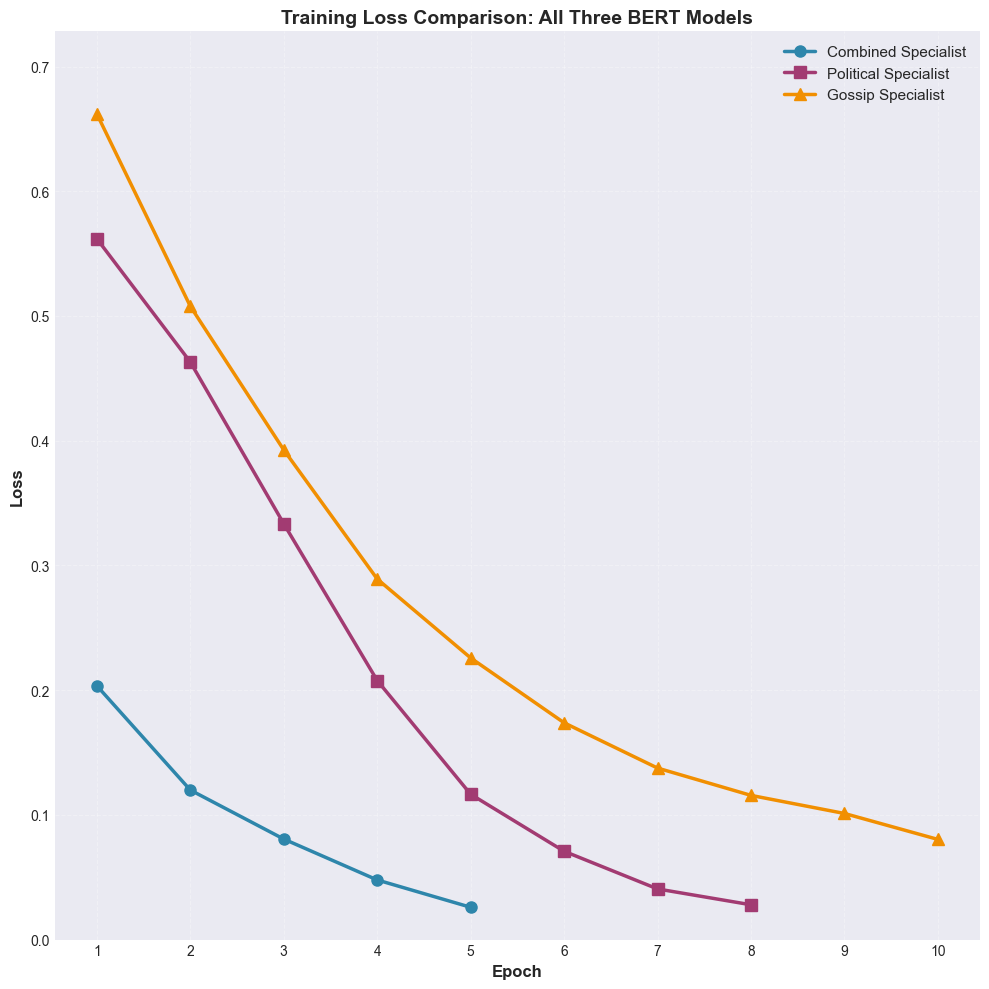


📊 LOSS CURVE SUMMARY STATISTICS

🔵 Combined Specialist Model:
  Epochs Trained: 5
  Initial Loss: 0.2035
  Final Loss: 0.0259
  Loss Reduction: 0.1776 (87.3%)
  Training Rate: 0.0355 loss/epoch

🟣 Political Specialist Model:
  Epochs Trained: 8
  Initial Loss: 0.5619
  Final Loss: 0.0279
  Loss Reduction: 0.5340 (95.0%)
  Training Rate: 0.0667 loss/epoch

🟠 Gossip Specialist Model:
  Epochs Trained: 10
  Initial Loss: 0.6620
  Final Loss: 0.0803
  Loss Reduction: 0.5817 (87.9%)
  Training Rate: 0.0582 loss/epoch

📈 KEY INSIGHTS:

✓ Combined Specialist converged fastest (lowest final loss after 5 epochs): 0.0259
✓ Political Specialist needed 8 epochs to converge, starting from higher loss: 0.5619
✓ Gossip Specialist trained for 10 epochs with steady loss reduction

✓ All models show consistent downward loss trends
✓ The Combined Specialist achieved the lowest overall loss: 0.0259
✓ Different domain specialists required different training schedules for optimal convergence


In [10]:
# Loss curves from all three models during training

# Combined Specialist Model (bert_fake_news_trained_v2)
combined_epochs = list(range(1, 6))
combined_losses = [0.2035, 0.1199, 0.0806, 0.0478, 0.0259]

# Political Specialist Model (bert_politifact_retrained)
political_epochs = list(range(1, 9))
political_losses = [0.5619, 0.4631, 0.3334, 0.2077, 0.1165, 0.0708, 0.0406, 0.0279]

# Gossip Specialist Model (bert_gossip)
gossip_epochs = list(range(1, 11))
gossip_losses = [0.6620, 0.5078, 0.3926, 0.2891, 0.2258, 0.1738, 0.1375, 0.1156, 0.1011, 0.0803]

# Create the combined plot (square for LaTeX)
plt.figure(figsize=(10, 10))

# Plot all three loss curves
plt.plot(combined_epochs, combined_losses, marker='o', linewidth=2.5, markersize=8, 
         label='Combined Specialist', color='#2E86AB')
plt.plot(political_epochs, political_losses, marker='s', linewidth=2.5, markersize=8, 
         label='Political Specialist', color='#A23B72')
plt.plot(gossip_epochs, gossip_losses, marker='^', linewidth=2.5, markersize=8, 
         label='Gossip Specialist', color='#F18F01')

# Styling
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss Comparison: All Three BERT Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')

# Set x-axis to show all epoch numbers
plt.xticks(range(1, 11))

# Add some padding to y-axis
plt.ylim(0, max(gossip_losses) * 1.1)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("📊 LOSS CURVE SUMMARY STATISTICS")
print("="*80)

print(f"\n🔵 Combined Specialist Model:")
print(f"  Epochs Trained: {len(combined_epochs)}")
print(f"  Initial Loss: {combined_losses[0]:.4f}")
print(f"  Final Loss: {combined_losses[-1]:.4f}")
print(f"  Loss Reduction: {(combined_losses[0] - combined_losses[-1]):.4f} ({((combined_losses[0] - combined_losses[-1])/combined_losses[0]*100):.1f}%)")
print(f"  Training Rate: {(combined_losses[0] - combined_losses[-1])/len(combined_epochs):.4f} loss/epoch")

print(f"\n🟣 Political Specialist Model:")
print(f"  Epochs Trained: {len(political_epochs)}")
print(f"  Initial Loss: {political_losses[0]:.4f}")
print(f"  Final Loss: {political_losses[-1]:.4f}")
print(f"  Loss Reduction: {(political_losses[0] - political_losses[-1]):.4f} ({((political_losses[0] - political_losses[-1])/political_losses[0]*100):.1f}%)")
print(f"  Training Rate: {(political_losses[0] - political_losses[-1])/len(political_epochs):.4f} loss/epoch")

print(f"\n🟠 Gossip Specialist Model:")
print(f"  Epochs Trained: {len(gossip_epochs)}")
print(f"  Initial Loss: {gossip_losses[0]:.4f}")
print(f"  Final Loss: {gossip_losses[-1]:.4f}")
print(f"  Loss Reduction: {(gossip_losses[0] - gossip_losses[-1]):.4f} ({((gossip_losses[0] - gossip_losses[-1])/gossip_losses[0]*100):.1f}%)")
print(f"  Training Rate: {(gossip_losses[0] - gossip_losses[-1])/len(gossip_epochs):.4f} loss/epoch")

print(f"\n{'='*80}")
print("📈 KEY INSIGHTS:")
print(f"{'='*80}")
print(f"\n✓ Combined Specialist converged fastest (lowest final loss after 5 epochs): {combined_losses[-1]:.4f}")
print(f"✓ Political Specialist needed 8 epochs to converge, starting from higher loss: {political_losses[0]:.4f}")
print(f"✓ Gossip Specialist trained for 10 epochs with steady loss reduction")
print(f"\n✓ All models show consistent downward loss trends")
print(f"✓ The Combined Specialist achieved the lowest overall loss: {combined_losses[-1]:.4f}")
print(f"✓ Different domain specialists required different training schedules for optimal convergence")